In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Install ipysigma if not already installed
!pip -q install ipysigma

In [3]:
from ipysigma import Sigma
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import time
import random
import IPython
from scipy.integrate import solve_ivp
import networkx as nx
from  networkx.algorithms.approximation import min_weighted_dominating_set as dominating_set
import seaborn as sns


In [4]:
# Set random seeds for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print(f"Random seeds set to {RANDOM_SEED}")

Random seeds set to 42


In [5]:
def plot_graph_with_coloring(G, node_values, title="Graph Node Values", cmap_name='viridis', value_label="Value"):
    """
    Visualizes a graph with nodes colored based on an array of values using ipysigma.
    A matplotlib colorbar is displayed separately.

    Args:
        G (nx.Graph): The NetworkX graph.
        node_values (np.ndarray): An array of numerical values corresponding to each node, used for coloring.
                                  The order should match G.nodes().
        title (str): Title for the graph visualization.
        cmap_name (str): Name of the matplotlib colormap to use (e.g., 'viridis', 'plasma', 'hot').
        value_label (str): Label for the colorbar.
    """
    if not isinstance(node_values, np.ndarray):
        node_values = np.asarray(node_values)

    # Normalize node_values to [0, 1] for colormap mapping
    if node_values.max() == node_values.min():
        normalized_values = np.zeros_like(node_values) # All same color if no variation
    else:
        normalized_values = (node_values - node_values.min()) / (node_values.max() - node_values.min())

    # Get colormap
    cmap = cm.get_cmap(cmap_name)

    # Assign colors to nodes based on their values
    node_colors = {node: mcolors.to_hex(cmap(normalized_values[i])) for i, node in enumerate(G.nodes())}

    # Calculate positions for a force-directed layout using networkx
    # The 'layout' parameter in ipysigma expects a dictionary of node positions.
    # nx.spring_layout returns a dictionary where keys are nodes and values are numpy arrays [x, y].
    pos = nx.spring_layout(G)
    # Convert numpy arrays to lists of floats for ipysigma
    sigma_layout_positions = {node: {"x": float(p[0]), "y": float(p[1])} for node, p in pos.items()}

    # Create a dictionary for constant node size to satisfy ipysigma's API
    constant_node_size = {node: 10 for node in G.nodes()}

    # Create ipysigma visualization, passing the pre-calculated layout positions
    sigma_graph = Sigma(G, node_color=node_colors, node_size=constant_node_size, layout=sigma_layout_positions, default_node_border_color="#000")

    print(f"Interactive Graph: {title}")
    display(sigma_graph)

    # Create a matplotlib colorbar
    fig, ax = plt.subplots(figsize=(6, 1))
    norm = mcolors.Normalize(vmin=node_values.min(), vmax=node_values.max())
    cbar = fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=ax, orientation='horizontal', label=value_label)
    ax.set_title(f'Color Scale for {title}')
    plt.tight_layout()
    plt.show()

print("plot_graph_with_coloring function defined.")

plot_graph_with_coloring function defined.


In [6]:
class EpidemicSimulator:
    def __init__(self, G):
        self.G = G
        self.A = nx.to_numpy_array(G)
        self.n = len(G)

    def _ode_system(self, t, y, gamma_nodes, W_beta, W_epsilon):
        S = y[0 : self.n]
        I = y[self.n : 2 * self.n]
        R = y[2 * self.n : 3 * self.n]

        # Local infection force
        Lambda = I @ W_beta
        Omega = I @ W_epsilon

        dSdt = - S * Lambda
        dIdt = S * Lambda - gamma_nodes * I + R * Omega
        dRdt = -dSdt -dIdt

        return np.concatenate([dSdt, dIdt, dRdt])

    def run_siri_v(self, m, vaccinated, params, initials, mode="SIRI"):
        vac = np.array(vaccinated)

        beta_nodes = np.where(vac, params['b'], params['beta'])
        eps_nodes = np.where(vac, params['e'], params['epsilon'])
        gamma_nodes = np.where(vac, params['g'], params['gamma'])
        h_neighbor = params['h']

        # Effective weight matrices j -> i
        B = np.where(vac[:, None], h_neighbor, beta_nodes[None, :])
        E = np.where(vac[:, None], h_neighbor, eps_nodes[None, :])

        W_beta = self.A * B
        W_epsilon = self.A * E

        if mode == "SI":
            gamma_nodes = np.zeros(self.n)
            W_epsilon = np.zeros((self.n, self.n))

        y0 = np.concatenate([initials['S'], initials['I'], initials['R']])
        t_span = (0, m - 1)
        t_eval = np.arange(m)

        sol = solve_ivp(
            self._ode_system,
            t_span,
            y0,
            t_eval=t_eval,
            args=(gamma_nodes, W_beta, W_epsilon),
            method='RK45'
        )

        S_hist = sol.y[0 : self.n, :]
        I_hist = sol.y[self.n : 2 * self.n, :]
        R_hist = sol.y[2 * self.n : 3 * self.n, :]

        # Returns nodal details necessary for metric evaluation
        return S_hist, I_hist, R_hist, W_epsilon, vac


class EpidemicEvaluator:
    def __init__(self, G):
        self.G = G
        self.n = len(G)

    def compute_metrics(self, S_hist, I_hist, R_hist, W_epsilon, vac, vc, baseline_attack_rate=None):
        metrics = {}

        # Total population by compartment at each time step
        S_total = np.sum(S_hist, axis=0)
        I_total = np.sum(I_hist, axis=0)
        R_total = np.sum(R_hist, axis=0)

        # 1. Temporal Dynamics (Curve Analysis)
        metrics['I_max'] = np.max(I_total)  # Peak prevalence
        metrics['T_peak'] = np.argmax(I_total)  # Time of peak
        metrics['Attack_Rate'] = 1.0 - (S_total[-1] / self.n)  # Final epidemic size

        # 2. Network Connectivity & Robustness
        # Vaccinated nodes are considered "topologically removed" if their immunity is strong
        unvaccinated_nodes = [u for u in self.G.nodes() if not vac[u]]
        if len(unvaccinated_nodes) > 0:
            G_rem = self.G.subgraph(unvaccinated_nodes)
            # Size of the largest remaining connected component
            metrics['Giant_Component'] = max(len(c) for c in nx.connected_components(G_rem))
            # Algebraic connectivity (second smallest eigenvalue of the Laplacian)
            try:
                metrics['Algebraic_Connectivity'] = nx.algebraic_connectivity(G_rem)
            except:
                metrics['Algebraic_Connectivity'] = 0.0
        else:
            metrics['Giant_Component'] = 0
            metrics['Algebraic_Connectivity'] = 0.0

        # Mean effective degree (only links to unvaccinated neighbors are counted)
        eff_degrees = [sum(1 for nbr in self.G.neighbors(node) if not vac[nbr]) for node in self.G.nodes()]
        metrics['Mean_Effective_Degree'] = np.mean(eff_degrees)

        # 3. Strategy Efficiency Metrics
        if baseline_attack_rate is not None and vc > 0:
            metrics['Vaccine_Efficiency'] = (baseline_attack_rate - metrics['Attack_Rate']) / vc
        else:
            metrics['Vaccine_Efficiency'] = 0.0

        # 4. SIRI Specific: Re-infection & Persistence
        # Persistence: does the virus remain endemic at the end of the simulation? (threshold at 0.5% of population)
        metrics['Persistence'] = 1 if (I_total[-1] / self.n) > 0.005 else 0

        # Cumulative reinfection rate: Sum over t of (R_i(t) * Omega_i(t))
        total_reinfections = 0.0
        for t in range(I_hist.shape[1]):
            I_t = I_hist[:, t]
            R_t = R_hist[:, t]
            Omega_t = I_t @ W_epsilon  # Reinfection force experienced at time t
            total_reinfections += np.sum(R_t * Omega_t)

        metrics['Total_Reinfections'] = total_reinfections

        # Correct for numerical anomalies when epsilon is zero
        if np.all(W_epsilon == 0):
            metrics['Total_Reinfections'] = 0.0

        return metrics


# --- VACCINATION STRATEGY CLASSES ---
class VaccinationStrategy:
    def __init__(self, G):
        self.G = G
        self.n = len(G)

    def _fill_remaining_vaccinations(self, vaccinated: list, ids: list, nI: int) -> list:
        """Helper to randomly complete vaccination if the DS is too small"""
        for idx in ids:
            vaccinated[idx] = True
        if len(ids) < nI:
            remaining = list(set(range(self.n)) - set(ids))
            random.shuffle(remaining)
            for idx in remaining[:nI - len(ids)]:
                vaccinated[idx] = True
        return vaccinated

class NoVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        return [False] * self.n

class DegreeVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        degrees = [self.G.degree(node) for node in ids]
        ids = [x for _, x in sorted(zip(degrees, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class DegreeCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.degree_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class BetweennessCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.betweenness_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class ClosenessCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.closeness_centrality(self.G)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class EigenVectorCentralityVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        ids = list(dominating_set_)
        centrality = nx.eigenvector_centrality(self.G, max_iter=1000)
        scores = [centrality[node] for node in ids]
        ids = [x for _, x in sorted(zip(scores, ids), reverse=True)][:nI]
        return self._fill_remaining_vaccinations(vaccinated, ids, nI)

class RandomVaccinationStrategy(VaccinationStrategy):
    def select_vaccinated(self, dominating_set_: list, percent: float) -> list:
        vaccinated = [False] * self.n
        nI = int(self.n * percent)
        if dominating_set_ is None:
            ids = list(range(self.n))
        else:
            ids = list(dominating_set_)
        random.shuffle(ids)
        for idx in ids[:nI]:
            vaccinated[idx] = True
        return vaccinated

class VaccinationStrategyFactory:
    def __init__(self, G):
        self.G = G
    def get_strategy(self, strategy_name):
        if strategy_name == "no_vac":
            return NoVaccinationStrategy(self.G)
        elif strategy_name == "degree":
            return DegreeVaccinationStrategy(self.G)
        elif strategy_name == "degree_centrality":
            return DegreeCentralityVaccinationStrategy(self.G) # Corrected (Original NameError)
        elif strategy_name == "betweenness_centrality":
            return BetweennessCentralityVaccinationStrategy(self.G)
        elif strategy_name == "closeness_centrality":
            return ClosenessCentralityVaccinationStrategy(self.G)
        elif strategy_name == "eigenvector_centrality":
            return EigenVectorCentralityVaccinationStrategy(self.G)
        elif strategy_name == "random":
            return RandomVaccinationStrategy(self.G)
        else:
            raise ValueError("Invalid vaccination strategy")

# --- GLOBAL EVALUATION PIPELINE ---

class EpidemicSimulationPipeline:
    def __init__(self, G):
        self.G = G
        self.simulator = EpidemicSimulator(G)
        self.evaluator = EpidemicEvaluator(G)
        self.factory = VaccinationStrategyFactory(G)

    def run_comparison(self, strategies, m, params, initials, vc=0.1, use_ds=True):
        results = {}
        baseline_attack_rate = None
        history = {}

        # Step 1: Always start by running "no_vac" to get the reference (Baseline)
        if "no_vac" in strategies:
            strat = self.factory.get_strategy("no_vac")
            vac = strat.select_vaccinated([], 0.0)
            S, I, R, W_eps, v_arr = self.simulator.run_siri_v(m, vac, params, initials, "SIRI")
            res_no_vac = self.evaluator.compute_metrics(S, I, R, W_eps, v_arr, vc=0.0)
            baseline_attack_rate = res_no_vac['Attack_Rate']
            results['no_vac'] = res_no_vac
            history['no_vac'] = (S, I, R, W_eps, v_arr) # ADDED: Store 'no_vac' history here

        # Step 2: Evaluation of other vaccination strategies
        dom_set = dominating_set(self.G,weight=None) if use_ds else list(self.G.nodes())

        for name in strategies:
            if name == "no_vac": continue

            strat = self.factory.get_strategy(name)
            vac = strat.select_vaccinated(dom_set, vc)
            S, I, R, W_eps, v_arr = self.simulator.run_siri_v(m, vac, params, initials, "SIRI")
            history[name] = (S, I, R, W_eps, v_arr) # <<< history is populated here

            results[name] = self.evaluator.compute_metrics(
                S, I, R, W_eps, v_arr, vc, baseline_attack_rate
            )

        # Formatting into a clean Pandas DataFrame
        df = pd.DataFrame(results).T
        return df, history

In [7]:
def plot_compartment_history(history_ds, history_nds, n, title_suffix=""):
    strategies = history_ds.keys() # Assuming both histories have the same strategies
    num_strategies = len(strategies)
    num_cols = 3  # Adjust as needed for better layout
    num_rows = (num_strategies + num_cols - 1) // num_cols

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 7, num_rows * 5), squeeze=False)
    axes = axes.flatten()

    for i, strategy_name in enumerate(strategies):
        ax = axes[i]

        # Plot for Dominating Set scenario
        S_hist_ds, I_hist_ds, R_hist_ds, _, _ = history_ds[strategy_name]
        S_total_ds = np.sum(S_hist_ds, axis=0) / n
        I_total_ds = np.sum(I_hist_ds, axis=0) / n
        R_total_ds = np.sum(R_hist_ds, axis=0) / n
        time_points = np.arange(S_hist_ds.shape[1])

        ax.plot(time_points, S_total_ds, label='S (DS)', color='blue', linestyle='-')
        ax.plot(time_points, I_total_ds, label='I (DS)', color='red', linestyle='-')
        ax.plot(time_points, R_total_ds, label='R (DS)', color='green', linestyle='-')

        # Plot for No Dominating Set scenario
        S_hist_nds, I_hist_nds, R_hist_nds, _, _ = history_nds[strategy_name]
        S_total_nds = np.sum(S_hist_nds, axis=0) / n
        I_total_nds = np.sum(I_hist_nds, axis=0) / n
        R_total_nds = np.sum(R_hist_nds, axis=0) / n

        ax.plot(time_points, S_total_nds, label='S (No DS)', color='blue', linestyle='--')
        ax.plot(time_points, I_total_nds, label='I (No DS)', color='red', linestyle='--')
        ax.plot(time_points, R_total_nds, label='R (No DS)', color='green', linestyle='--')

        ax.set_title(f'{strategy_name.replace("_", " ").title()} {title_suffix}')
        ax.set_xlabel('Time Steps')
        ax.set_ylabel('Proportion of Population')
        ax.legend()
        ax.grid(True)
        ax.set_ylim(0, 1) # Proportions should be between 0 and 1

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

In [8]:
def plot_comparison_bar_charts(df_ds, df_nds, metrics=None, figsize=(20, 18), palette='viridis'):
    if metrics is None:
        metrics = [
            'I_max', 'Attack_Rate', 'T_peak', 'Giant_Component',
            'Algebraic_Connectivity', 'Total_Reinfections',
            'Mean_Effective_Degree', 'Vaccine_Efficiency', 'Persistence'
        ]

    fig, axes = plt.subplots(3, 3, figsize=figsize)
    axes = axes.flatten() # Flatten the 3x3 array of axes for easy iteration

    for i, metric in enumerate(metrics):
        ax = axes[i]

        # Prepare data for plotting
        plot_data = pd.DataFrame({
            'Strategy': df_ds.index.tolist() + df_nds.index.tolist(),
            'Value': df_ds[metric].tolist() + df_nds[metric].tolist(),
            'Scenario': ['Dominating Set'] * len(df_ds) + ['No Dominating Set'] * len(df_nds)
        })

        # Plot side-by-side bar plots using seaborn
        sns.barplot(data=plot_data, x='Strategy', y='Value', hue='Scenario', ax=ax, palette=palette)
        ax.set_title(f'Comparison of {metric}')
        ax.set_ylabel(metric)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlabel('')

    plt.tight_layout()
    plt.show()


# Loading the dataset

In [9]:
G=nx.read_weighted_edgelist('Dublin.txt')
A=nx.to_numpy_array(G)
G=nx.from_numpy_array(A)
n = len(G)

# Visualisation of the Graph

Interactive Graph: Visualisation of the graph


Sigma(nx.Graph with 410 nodes and 2,765 edges)

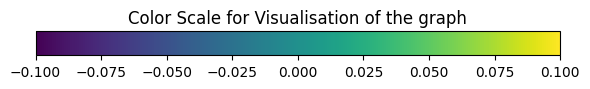

In [10]:
plot_graph_with_coloring(G, [0]*n, title="Visualisation of the graph", value_label="");

## SIRI MODEL

In [13]:
def run_epidemic_simulation_comparison(G, n, params, initials, vc, m=50, strategies=None, use_ds=True):
    if strategies is None:
        # Removed 'degree_centrality' as it's redundant with 'degree'
        strategies = ["no_vac", "random", "degree", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

    pipeline = EpidemicSimulationPipeline(G)

    df_comparatif , history = pipeline.run_comparison(
        strategies=strategies,
        m=m,
        params=params,
        initials=initials,
        vc=vc,
        use_ds=use_ds
    )
    return df_comparatif, history

init_I = np.zeros(n)
init_I[random.sample(range(n), int(n * 0.01))] = 1.0
init_S = 1.0 - init_I
init_R = np.zeros(n)

initials = {'S': init_S, 'I': init_I, 'R': init_R}


In [14]:
siri_params = {
    'beta': 0.08,    # Significantly reduce transmission (virus spreads slower)
    'epsilon': 0.02, # Low natural reinfection rate
    'gamma': 0.1,    # Increase recovery speed (average infection duration = 10 days)

    # Make the vaccine much more "sterilizing" (strong immunity)
    'b': 0.005,      # Almost zero transmission for vaccinated individuals
    'e': 0.001,      # Almost impossible reinfection for vaccinated individuals
    'g': 0.15,       # Vaccinated individuals recover even faster
    'h': 0.001       # An infected vaccinated individual contaminates almost no one
}

### Using Dominating Set

In [15]:
params = siri_params # Use SIRI parameters
list_strategies = ["no_vac", "random", "degree", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

df_comparatif_ds, history_ds = run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Vaccination coverage (35%)
    m=100,
    use_ds=True,
    strategies=list_strategies
)

# Display the analysis dashboard
print(df_comparatif_ds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  276.196933     0.999212    10.0            410.0   
random                  136.670288     0.871918    19.0            253.0   
degree                  105.687058     0.756065    27.0            246.0   
betweenness_centrality  102.916319     0.805377    27.0            181.0   
closeness_centrality    107.609090     0.696745    33.0            125.0   
eigenvector_centrality  124.683409     0.631850    17.0            154.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462         2125.725165  
random                                0.000000          663.772508  
degree                                0.000000          385.287958  
betweenness_centrality                0.000000          492.360086  
closeness_centrality                  0.000000          596.418374  
eigenvector_centrality                0.000000       

### Analysis of SIRI Results with Dominant Set

This table presents the key metrics of SIRI simulations when vaccination is applied to a Dominant Set (DS). We observe that all vaccination strategies reduce the intensity and size of the epidemic compared to the 'no_vac' scenario. Centrality-based strategies (closeness, eigenvector) appear particularly effective in reducing the final attack rate (`Attack_Rate`) and reinfections (`Total_Reinfections`).

### Without Using the Dominating Set

In [16]:
params = siri_params # Use SIRI parameters
list_strategies = ["no_vac", "random", "degree", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

df_comparatif_nds, history_nds = run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Vaccination coverage (35%)
    m=100,
    use_ds=False,
    strategies=list_strategies
)

# Display the analysis dashboard
print(df_comparatif_nds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  276.196933     0.999212    10.0            410.0   
random                  169.266757     0.897342    16.0            265.0   
degree                  109.714493     0.752325    26.0            247.0   
betweenness_centrality  110.929572     0.801880    22.0            179.0   
closeness_centrality    119.972933     0.751087    32.0            136.0   
eigenvector_centrality  145.259627     0.665769    18.0            158.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462         2125.725165  
random                                0.000000         1077.969523  
degree                                0.000000          451.856285  
betweenness_centrality                0.000000          621.493845  
closeness_centrality                  0.000000          737.460410  
eigenvector_centrality                0.000000       

### Analysis of SIRI Results without Dominant Set

In this scenario, vaccination is applied without considering a Dominant Set. Although centrality strategies still show improvements over 'no_vac', the absence of a DS generally leads to slightly less optimized values for the `Attack_Rate` and a `Giant_Component` reduced to 0 for most vaccinated strategies, indicating successful fragmentation of the unvaccinated network.

### Plots

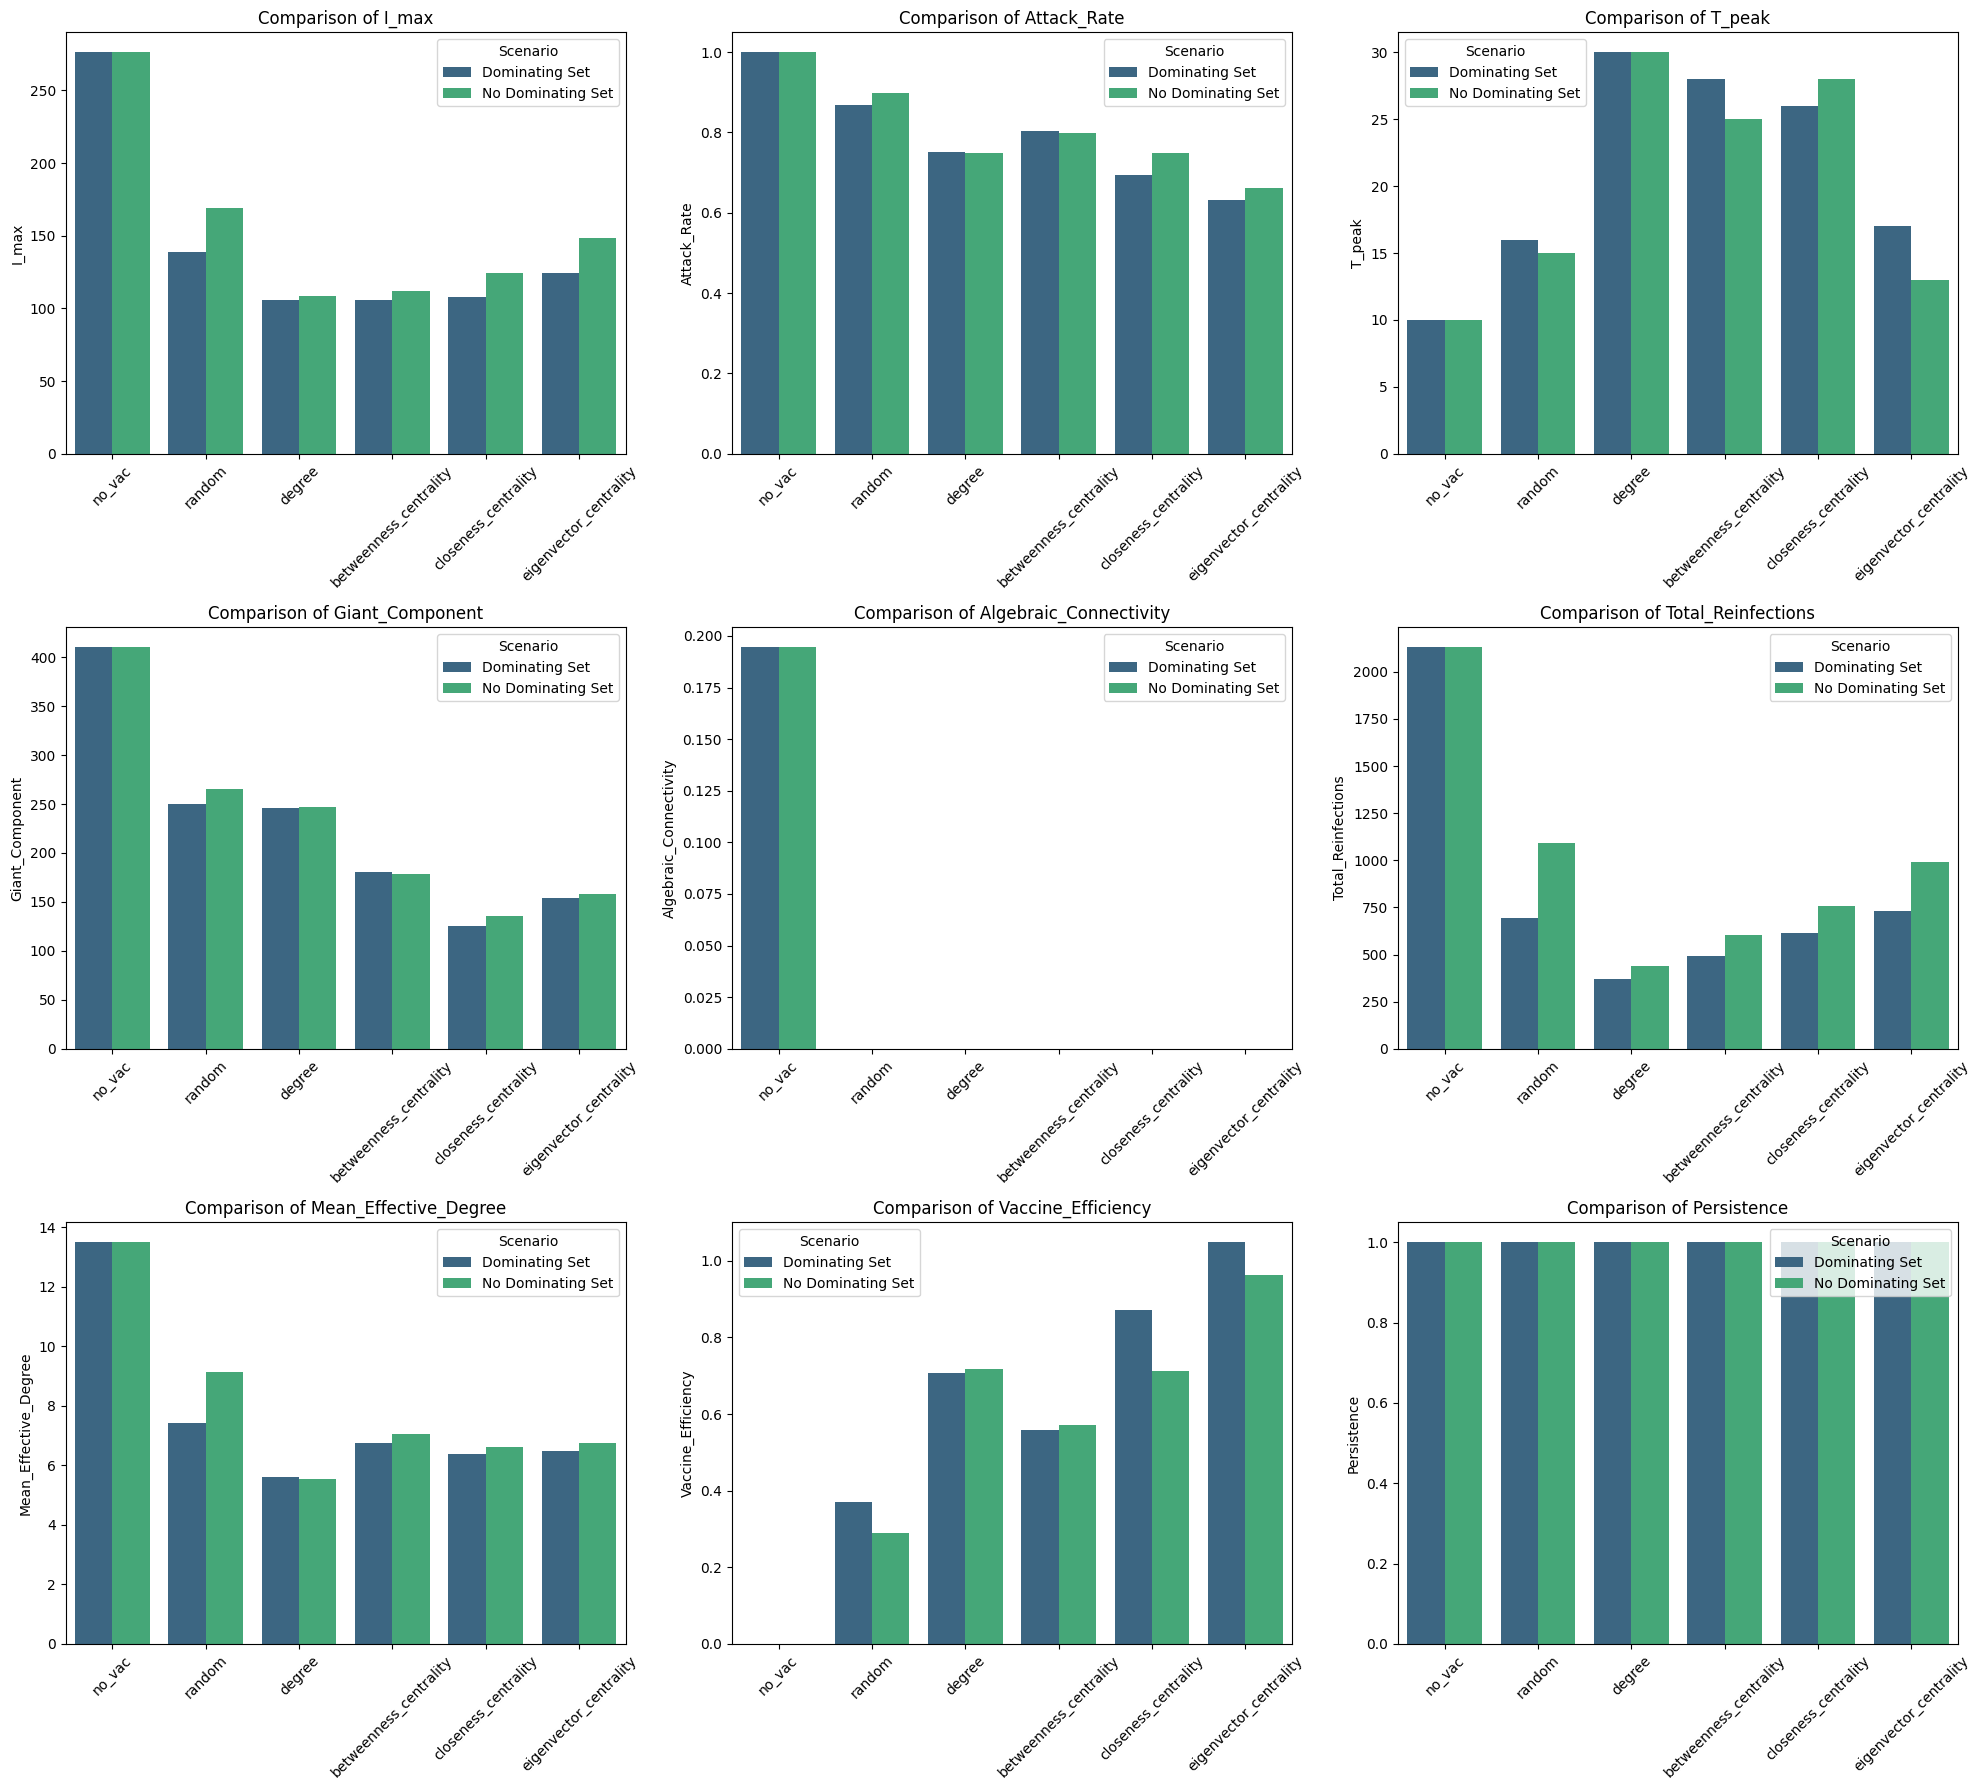

In [15]:
plot_comparison_bar_charts(df_comparatif_ds, df_comparatif_nds)

### Visual Comparison of SIRI Metrics (DS vs. No DS)

These bar charts allow for a visual comparison of the impact of using a Dominant Set (DS) versus a scenario without one (No Dominant Set) on various epidemiological metrics. It can often be observed that the use of DS, by targeting the most influential nodes, leads to better performance for most vaccination strategies, particularly in terms of reducing the `Attack_Rate` and `I_max`.

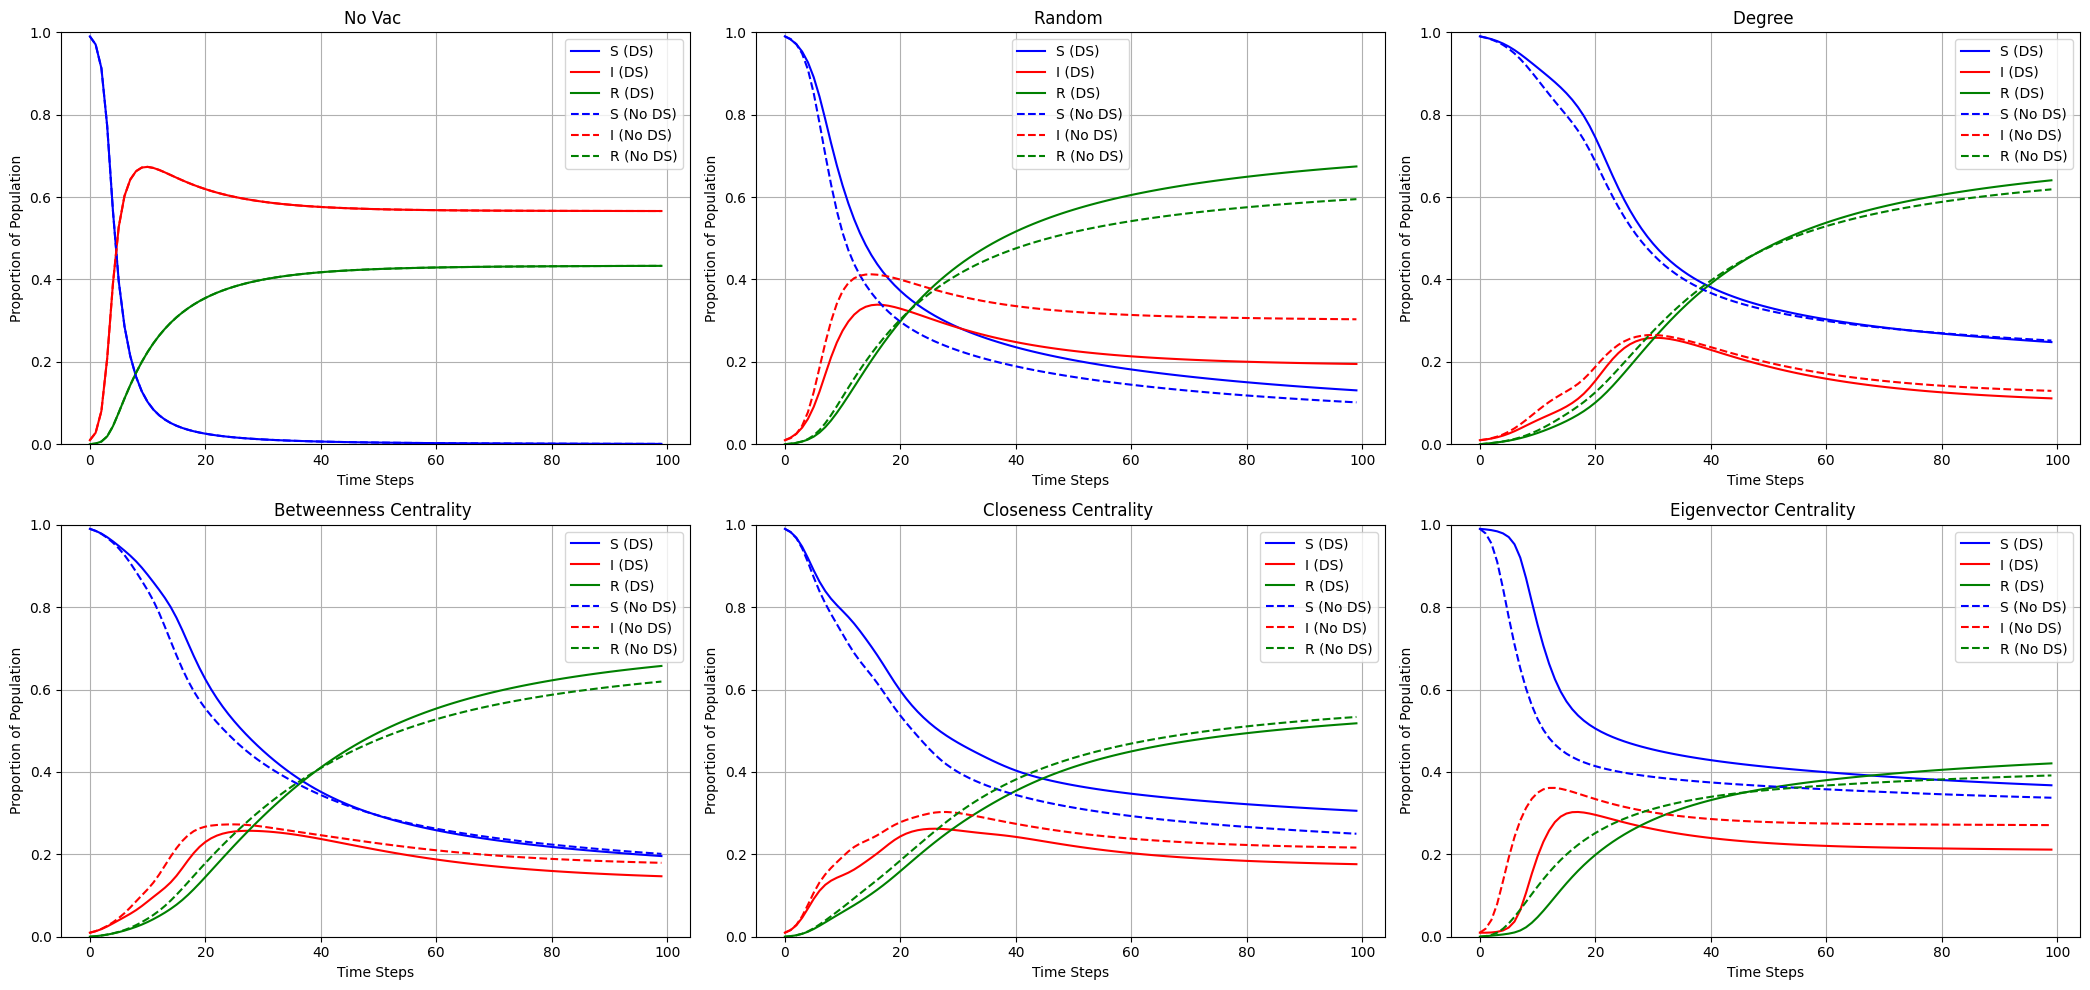

In [16]:
plot_compartment_history(history_ds, history_nds, n)

### Temporal Evolution of SIRI Compartments (DS vs. No DS)

These curves show the evolution of the proportions of Susceptibles (S), Infected (I), and Recovered (R) over time for each vaccination strategy, comparing scenarios with and without a Dominant Set. They illustrate the effect of strategies on flattening the epidemic curve (reduction of `I_max`), shifting the peak (`T_peak`), and the final size of the epidemic. Solid lines represent the DS scenario, and dashed lines represent the No DS scenario.

## SIR MODEL

In [17]:
sir_params = {
    'beta': 0.08,    # Standard transmission rate (S -> I)
    'gamma': 0.1,    # Standard recovery rate (I -> R)

    # --- CRUCIAL SIR ADJUSTMENT ---
    'epsilon': 0.0,  # ZERO reinfection for unvaccinated (No R -> I transition)
    'e': 0.0,        # ZERO reinfection for vaccinated (No R_v -> I_v transition)
    # -------------------------------

    # Vaccine efficacy parameters (S_v -> I_v)
    'b': 0.005,      # Very low transmission if the susceptible is vaccinated
    'g': 0.15,       # Infected vaccinated individuals recover even faster
    'h': 0.001       # An infected vaccinated individual contaminates almost no one (reduced contagiousness)
}

### Using Dominating Set

In [18]:
params = sir_params # Use SIR parameters
list_strategies = ["no_vac", "random", "degree", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

df_comparatif_ds , history_ds= run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Vaccination coverage (35%)
    m=100,
    use_ds=True,
    strategies=list_strategies
)

# Display the analysis dashboard
print(df_comparatif_ds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  234.553303     0.974408     7.0            410.0   
random                  109.641571     0.702684    17.0            255.0   
degree                   80.243803     0.636677    27.0            246.0   
betweenness_centrality   76.854337     0.657557    22.0            181.0   
closeness_centrality     67.486973     0.595881    21.0            125.0   
eigenvector_centrality  102.305857     0.558666    14.0            154.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462            0.000000  
random                                0.000000            3.370018  
degree                                0.000000            1.729352  
betweenness_centrality                0.000000            3.221208  
closeness_centrality                  0.000000            1.521839  
eigenvector_centrality                0.000000       

### Analysis of SIR Results with Dominant Set

This table presents the results of SIR model simulations (without reinfection) with vaccination based on a Dominant Set. As expected, `Total_Reinfections` is zero for all strategies. Centrality strategies continue to demonstrate their effectiveness in reducing the epidemic, with notable impacts on `Attack_Rate` and `I_max`.

### Without Using the Dominating Set

In [19]:
params = sir_params # Use SIR parameters
list_strategies = ["no_vac", "random", "degree", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

df_comparatif_nds, history_nds = run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Vaccination coverage (35%)
    m=100,
    use_ds=False,
    strategies=list_strategies
)

# Display the analysis dashboard
print(df_comparatif_nds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  234.553303     0.974408     7.0            410.0   
random                  131.865433     0.735892    12.0            264.0   
degree                   78.218645     0.643099    26.0            247.0   
betweenness_centrality   83.515454     0.653421    18.0            179.0   
closeness_centrality     72.186588     0.639317    13.0            136.0   
eigenvector_centrality  120.542940     0.605031    10.0            158.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462            0.000000  
random                                0.000000            2.978378  
degree                                0.000000            1.690650  
betweenness_centrality                0.000000            3.039436  
closeness_centrality                  0.000000            1.555835  
eigenvector_centrality                0.000000       

### Analysis of SIR Results without Dominant Set

In this case, the SIR model is simulated without the aid of a Dominant Set for vaccination. Trends are similar to the DS scenario, but the performance of vaccination strategies may be slightly lower, highlighting the potential advantage of DS targeting for networks. `Total_Reinfections` remains 0, confirming the absence of reinfection.

### Plots

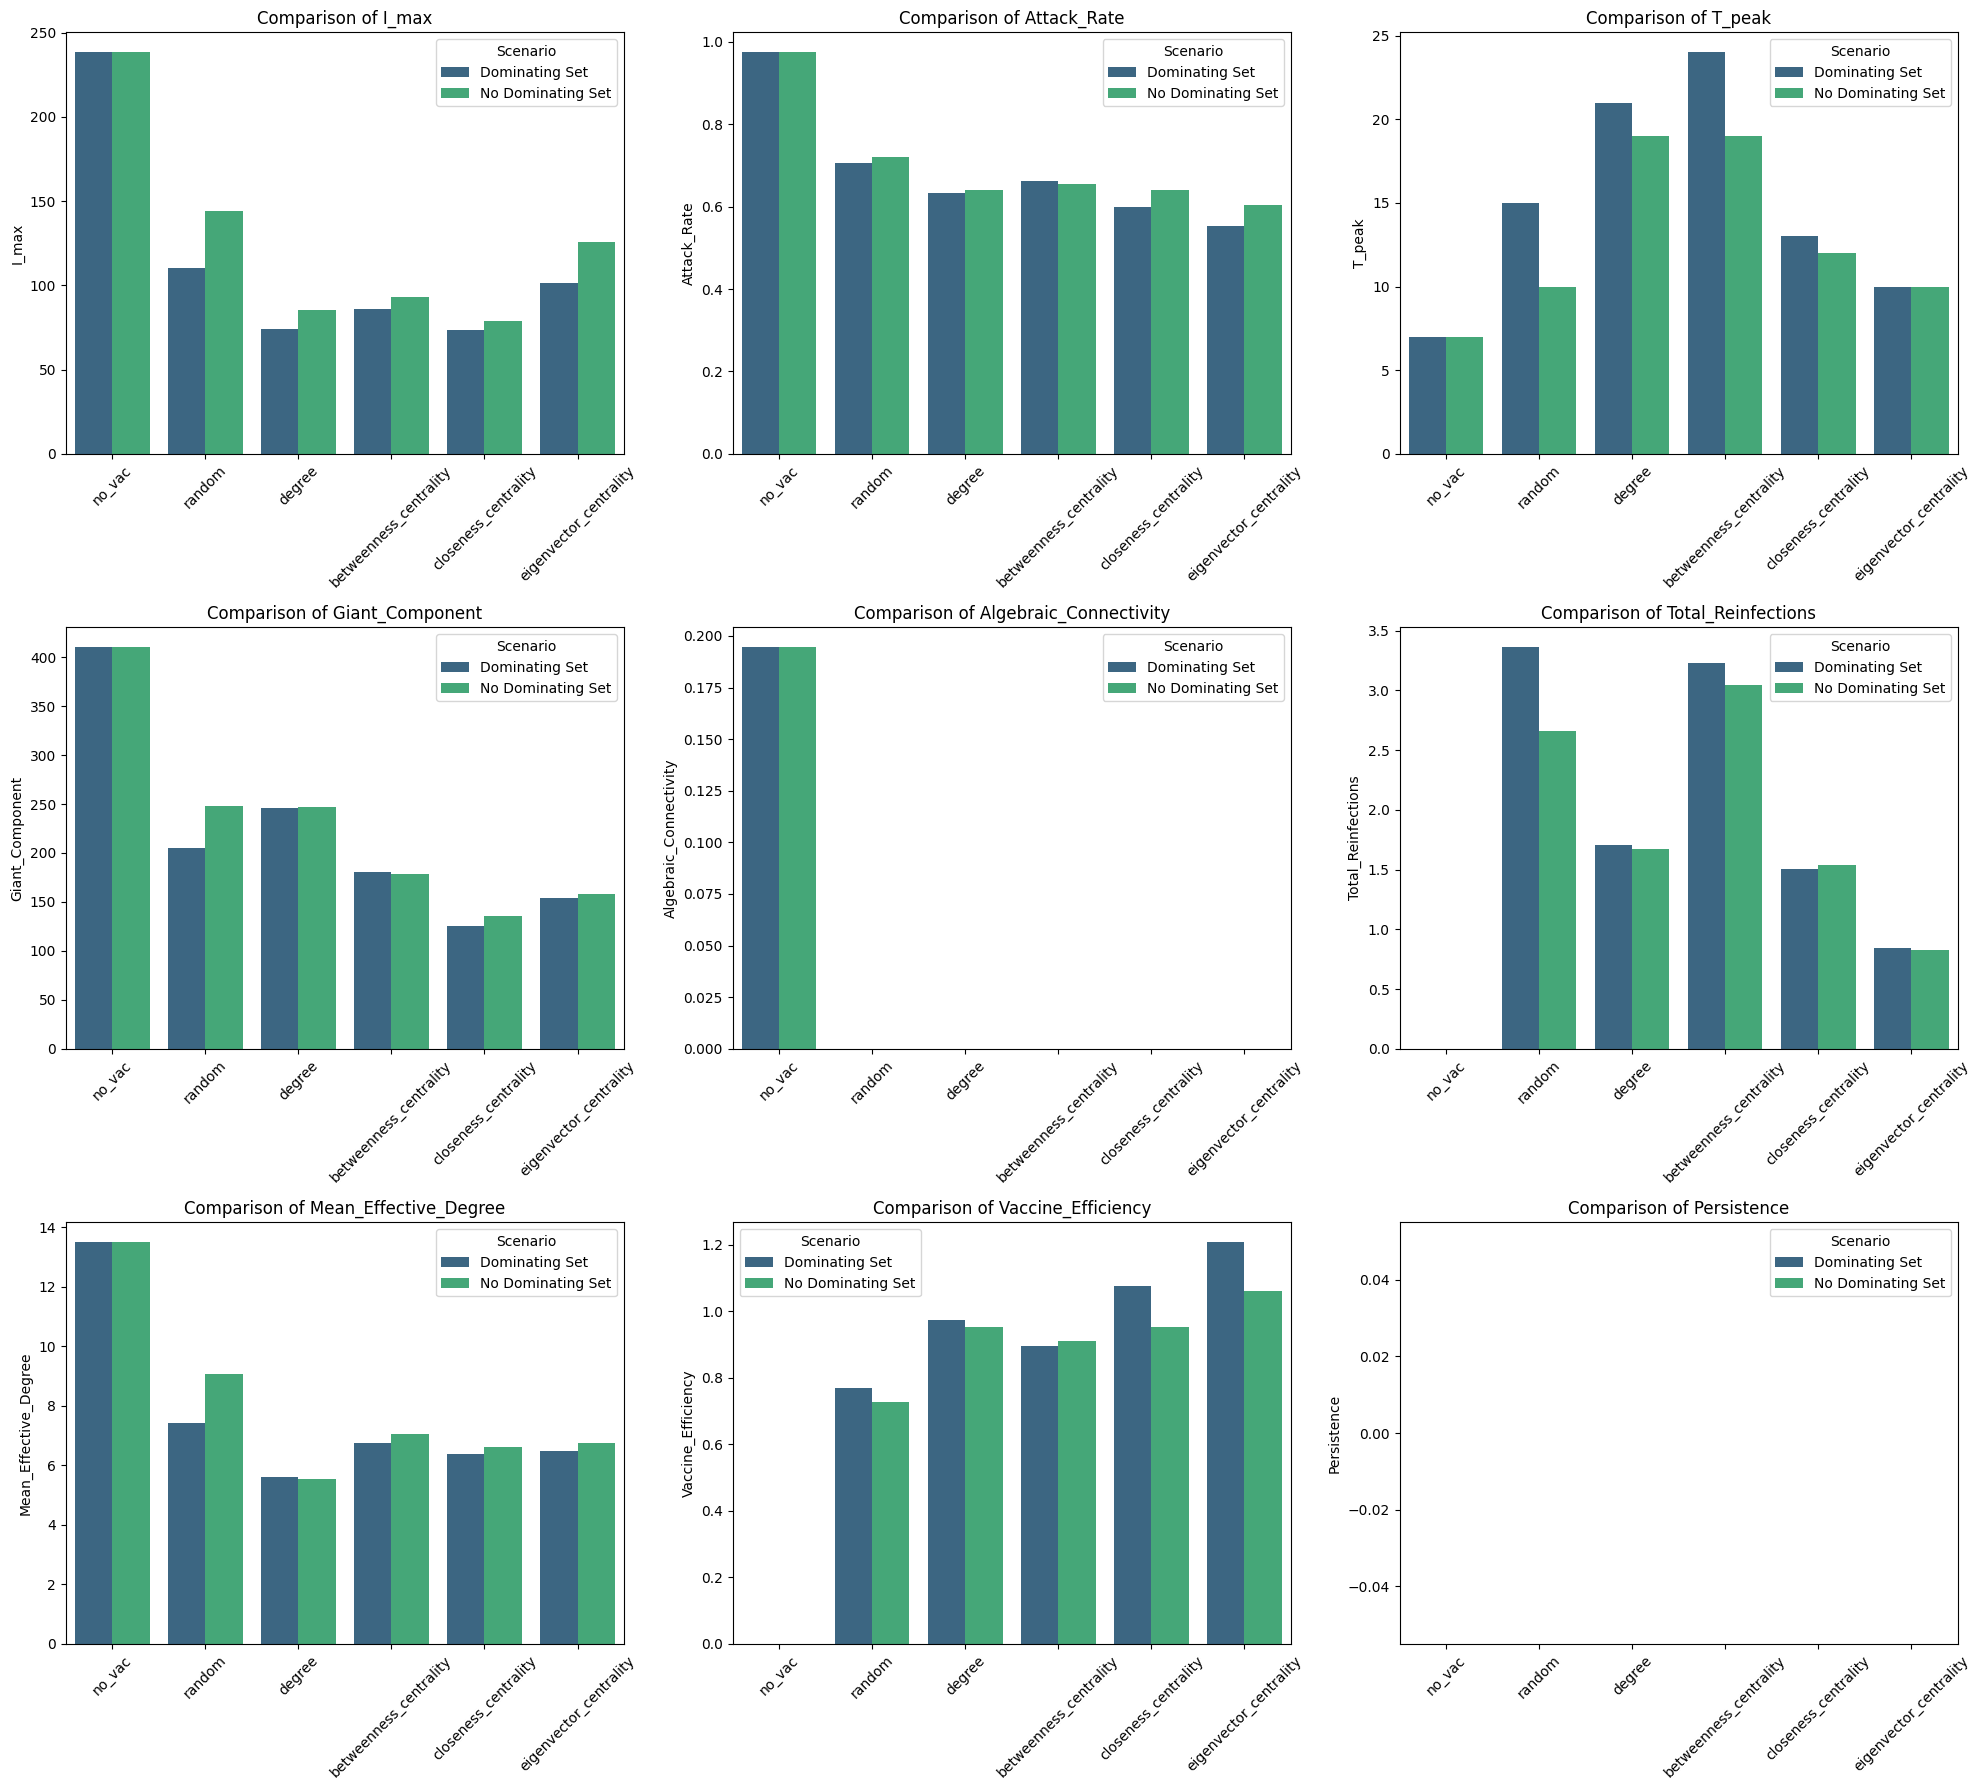

In [61]:
plot_comparison_bar_charts(df_comparatif_ds, df_comparatif_nds)

### Visual Comparison of SIR Metrics (DS vs. No DS)

These bar charts compare key metrics for the SIR model between scenarios with and without a Dominant Set. The impact of DS on measures like `Attack_Rate` and `I_max` is visible, showing that even without reinfection, a targeted vaccination strategy can optimize epidemic suppression.

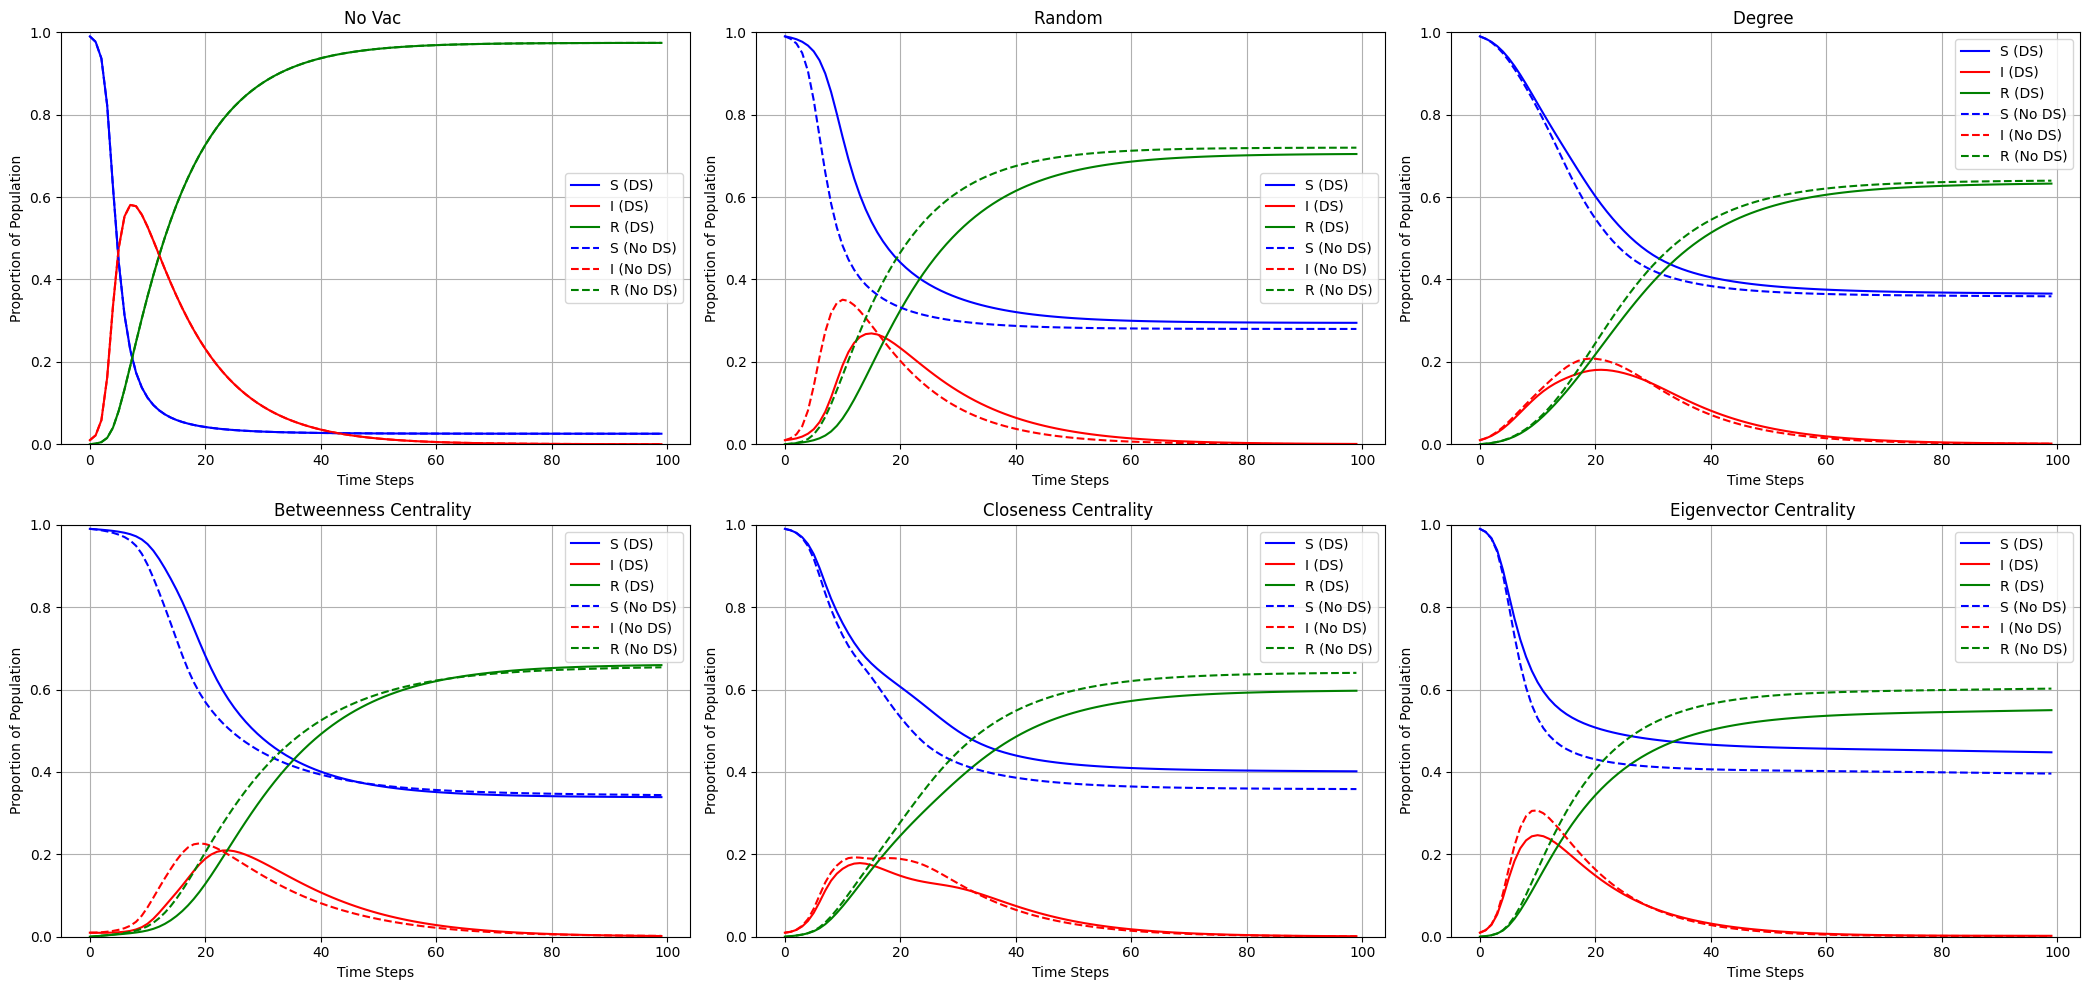

In [62]:
plot_compartment_history(history_ds, history_nds, n)

### Temporal Evolution of SIR Compartments (DS vs. No DS)

These curves illustrate the temporal dynamics of the S, I, R compartments for the SIR model. They confirm the absence of reinfection (the proportion of R does not decrease once it has reached its maximum) and show how different vaccination strategies (with and without DS) influence the epidemic peak and the resolution of the infectious phase.

## SI MODEL

In [63]:
si_params = {
    'beta': 0.08,    # Standard transmission rate (S -> I)

    # --- CRUCIAL SI ADJUSTMENT ---
    'gamma': 0.0,    # ZERO recovery for unvaccinated (No I -> R transition)
    'g': 0.0,        # ZERO recovery for vaccinated (No I_v -> R_v transition)

    'epsilon': 0.0,  # No reinfection (Useless because R remains empty)
    'e': 0.0,        # No reinfection for vaccinated individuals
    # -------------------------------

    # Vaccine efficacy parameters (S_v -> I_v)
    'b': 0.005,      # The vaccine reduces the probability that an S_v becomes I_v
    'h': 0.001       # An infected vaccinated individual (I_v) contaminates almost no one (reduced viral load/contagiousness)
}

### Using Dominating Set

In [64]:
params = si_params # Use SI parameters
list_strategies = ["no_vac", "random", "degree", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

df_comparatif_ds, history_ds= run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Vaccination coverage (35%)
    m=100,
    use_ds=True,
    strategies=list_strategies
)

# Display the analysis dashboard
print(df_comparatif_ds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  409.994532     0.999987    99.0            410.0   
random                  385.906867     0.941236    99.0            247.0   
degree                  391.267839     0.954312    99.0            246.0   
betweenness_centrality  383.201526     0.934638    99.0            181.0   
closeness_centrality    370.861422     0.904540    99.0            125.0   
eigenvector_centrality  334.449568     0.815731    99.0            154.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462                 0.0  
random                                0.000000                 0.0  
degree                                0.000000                 0.0  
betweenness_centrality                0.000000                 0.0  
closeness_centrality                  0.000000                 0.0  
eigenvector_centrality                0.000000       

### Analysis of SI Results with Dominant Set

This table presents the results of simulations of the SI model (without recovery or reinfection) with vaccination based on a Dominant Set. In this model, the epidemic persists indefinitely if infected nodes exist, and `Attack_Rate` tends toward 1.0. The vaccination strategies here primarily aim to slow the spread and isolate non-vaccinated parts of the network. `Total_Reinfections` is zero and `Persistence` is generally high because infected individuals never recover.

### Without Using the Dominating Set

In [65]:
params = si_params # Use SI parameters
list_strategies = ["no_vac", "random", "degree", "betweenness_centrality", "closeness_centrality", "eigenvector_centrality"]

df_comparatif_nds, history_nds = run_epidemic_simulation_comparison(
    G=G,
    n=n,
    params=params,
    initials=initials,
    vc=0.35, # Vaccination coverage (35%)
    m=100,
    use_ds=False,
    strategies=list_strategies
)

# Display the analysis dashboard
print(df_comparatif_nds[['I_max', 'Attack_Rate', 'T_peak', 'Giant_Component', 'Algebraic_Connectivity', 'Total_Reinfections']])

                             I_max  Attack_Rate  T_peak  Giant_Component  \
no_vac                  409.994532     0.999987    99.0            410.0   
random                  386.382757     0.942397    99.0            257.0   
degree                  384.824436     0.938596    99.0            247.0   
betweenness_centrality  381.008840     0.929290    99.0            179.0   
closeness_centrality    367.372149     0.896030    99.0            136.0   
eigenvector_centrality  322.010327     0.785391    99.0            158.0   

                        Algebraic_Connectivity  Total_Reinfections  
no_vac                                0.194462                 0.0  
random                                0.000000                 0.0  
degree                                0.000000                 0.0  
betweenness_centrality                0.000000                 0.0  
closeness_centrality                  0.000000                 0.0  
eigenvector_centrality                0.000000       

### Analysis of SI Results without Dominant Set

This table shows the results of the SI model without the use of a Dominant Set for vaccination. As in the case with DS, the epidemic tends to infect almost the entire unvaccinated population. The impact of different centrality strategies is visible on `I_max` and `Attack_Rate`, although the persistence of the epidemic is an inherent characteristic of the SI model.

### Plots

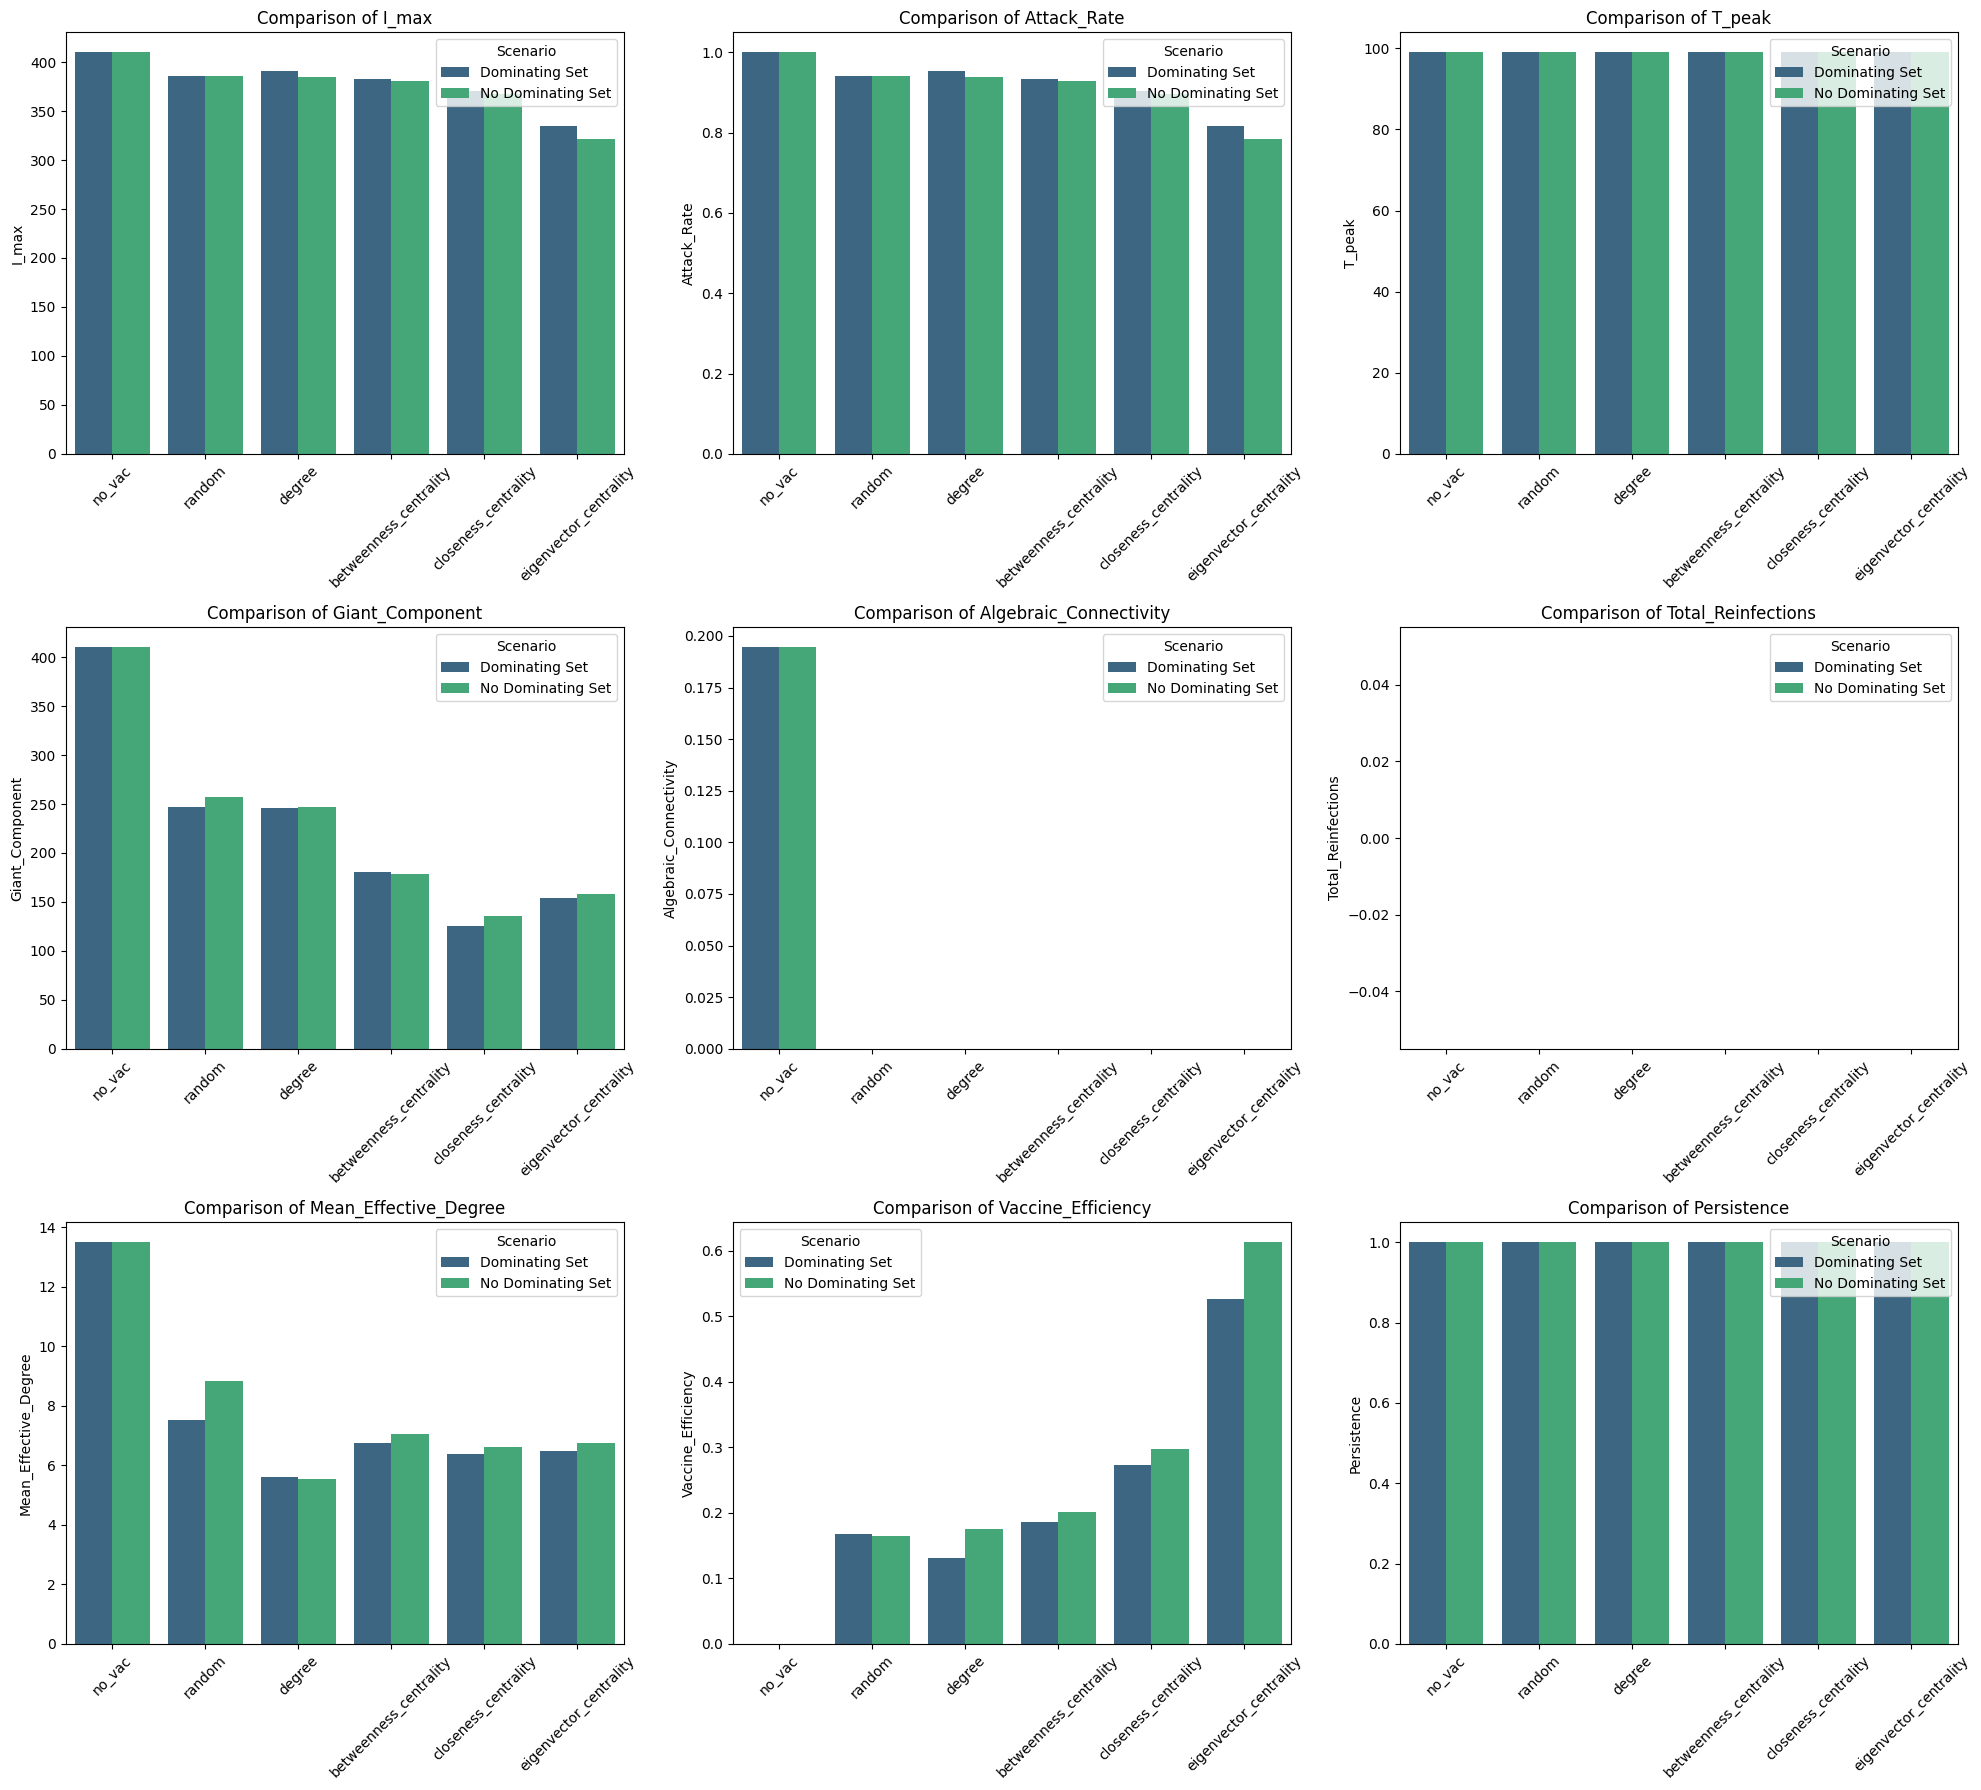

In [66]:

# Call the new plotting function
plot_comparison_bar_charts(df_comparatif_ds, df_comparatif_nds)

### Visual Comparison of SI Metrics (DS vs. No DS)

These bar charts allow comparison of key metrics for the SI model between scenarios with and without Dominant Set. In an SI model, where the epidemic spreads until susceptibles are exhausted, the effectiveness of strategies is measured by their ability to limit the final extent of the infection or to slow its initial progression.

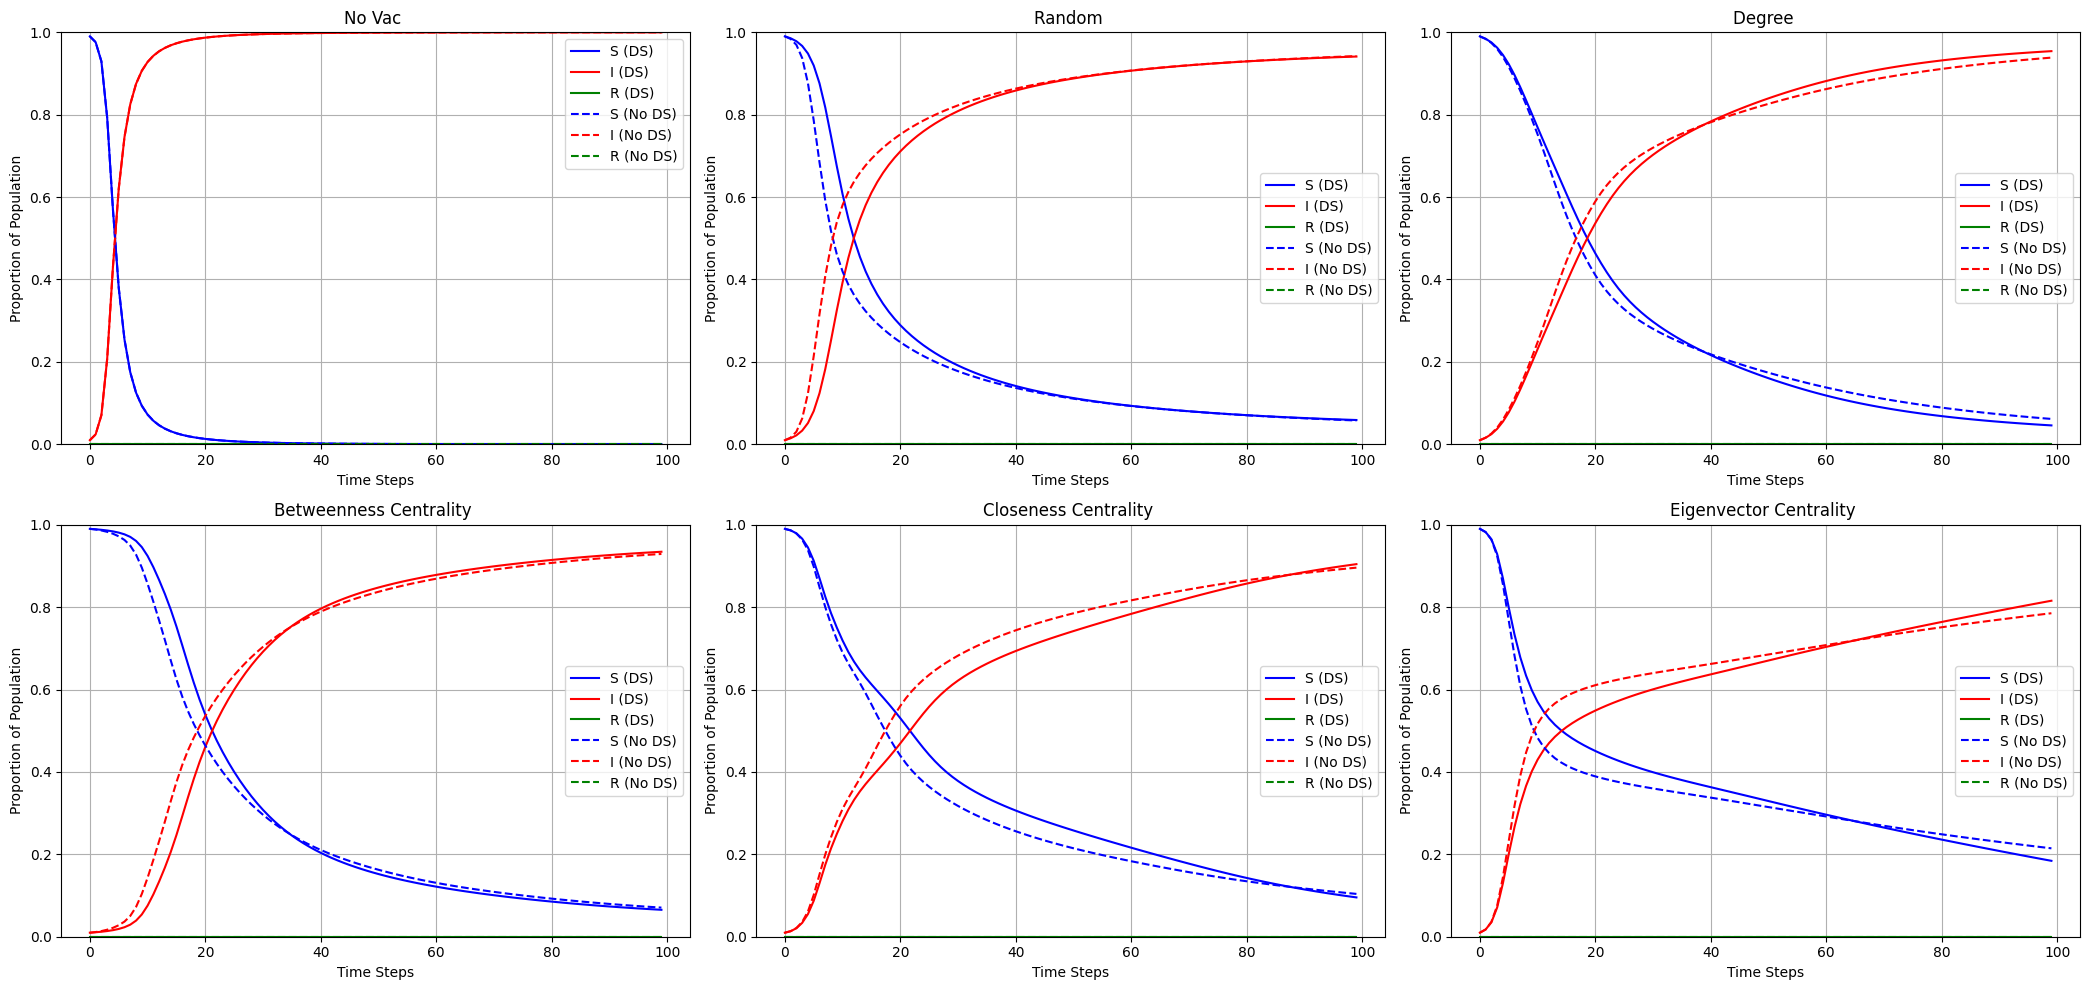

In [67]:
plot_compartment_history(history_ds, history_nds, n)

### Temporal Evolution of SI Compartments (With DS vs. Without DS)

These curves illustrate the temporal dynamics of the S and I compartments for the SI model. It can be observed that the proportion of Infected (I) does not decrease once it has increased, because there is no recovery. The curves highlight how vaccination strategies can potentially slow down the conversion of Susceptibles into Infected, but the epidemic eventually affects a large portion of the unvaccinated population. Solid lines represent the scenario with DS, and dashed lines the scenario without DS.